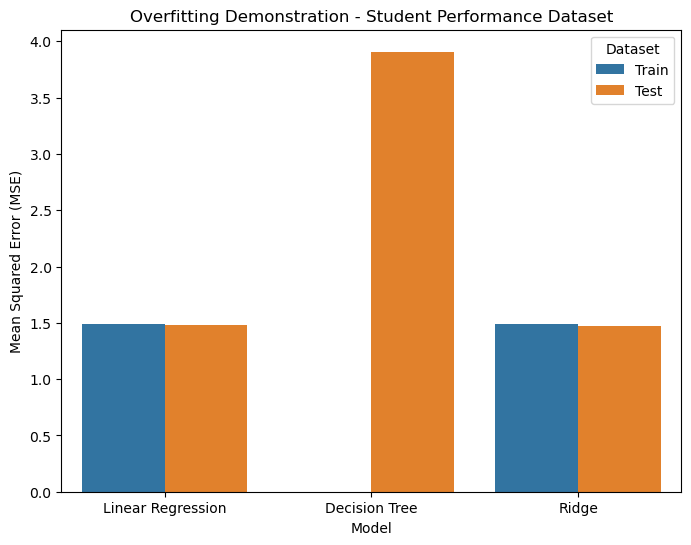

               Model Dataset       MSE
0  Linear Regression   Train  1.491112
1  Linear Regression    Test  1.476435
2      Decision Tree   Train  0.000000
3      Decision Tree    Test  3.907692
4              Ridge   Train  1.491355
5              Ridge    Test  1.474896


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# -------------------------------
# Step 1: Load the dataset
# -------------------------------
df = pd.read_csv("student-por.csv", sep=",")  # fixed separator

# Strip any whitespace from column names
df.columns = df.columns.str.strip()

# Verify that G3 column exists
if "G3" not in df.columns:
    raise ValueError(f"'G3' column not found! Available columns: {df.columns.tolist()}")

# Add noise feature
np.random.seed(42)
df["noise_feature"] = np.random.normal(0, 10, df.shape[0])

# -------------------------------
# Step 2: Prepare features & target
# -------------------------------
X = df.drop("G3", axis=1)
y = df["G3"]

# Convert categorical variables into numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Step 3: Train models
# -------------------------------
# Linear Regression
lin_reg = LinearRegression().fit(X_train, y_train)
y_pred_lin_train = lin_reg.predict(X_train)
y_pred_lin_test = lin_reg.predict(X_test)

# Decision Tree
tree = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)
y_pred_tree_train = tree.predict(X_train)
y_pred_tree_test = tree.predict(X_test)

# Ridge Regression
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
y_pred_ridge_train = ridge.predict(X_train)
y_pred_ridge_test = ridge.predict(X_test)

# -------------------------------
# Step 4: Evaluate
# -------------------------------
results = {
    "Model": ["Linear Regression", "Linear Regression", 
              "Decision Tree", "Decision Tree", 
              "Ridge", "Ridge"],
    "Dataset": ["Train", "Test", "Train", "Test", "Train", "Test"],
    "MSE": [
        mean_squared_error(y_train, y_pred_lin_train),
        mean_squared_error(y_test, y_pred_lin_test),
        mean_squared_error(y_train, y_pred_tree_train),
        mean_squared_error(y_test, y_pred_tree_test),
        mean_squared_error(y_train, y_pred_ridge_train),
        mean_squared_error(y_test, y_pred_ridge_test),
    ]
}

results_df = pd.DataFrame(results)

# -------------------------------
# Step 5: Visualization
# -------------------------------
plt.figure(figsize=(8, 6))
sns.barplot(data=results_df, x="Model", y="MSE", hue="Dataset")
plt.title("Overfitting Demonstration - Student Performance Dataset")
plt.ylabel("Mean Squared Error (MSE)")
plt.show()

# Print results
print(results_df)
